# Renaissance OCR Pipeline
This notebook walks through the preprocessing pipeline visually, then shows raw OCR output, cleaned text, and evaluation scores for each page.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np
from jiwer import wer, cer


In [2]:
output_dir= Path("/mnt/vstor/courses/csds312/cxv166/OCR/output/Guardiola - Tratado nobleza")
demo_page  = "p013"

page_dirs = sorted(output_dir.iterdir())


## 1. Preprocessing walkthrough
Each page goes through two stages: the original scan and binarisation, which is the image fed to the OCR model.

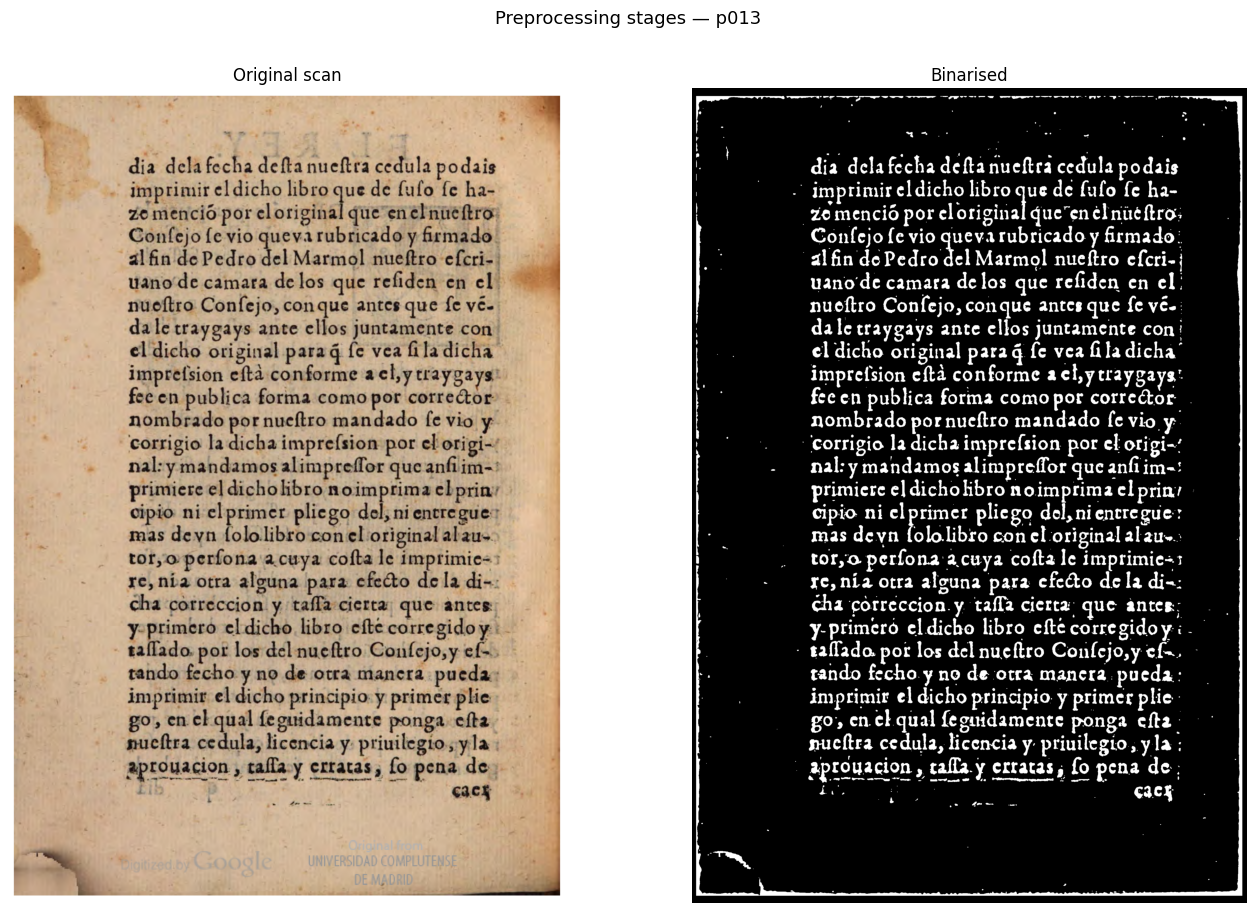

In [3]:
def show_preprocessing_stages(page_id: str):
    page_dir = Path("/mnt/vstor/courses/csds312/cxv166/OCR/output/Guardiola - Tratado nobleza") / page_id

    original = Image.open(page_dir / f"{page_id}.png")
    binary = Image.open(page_dir / f"{page_id}_binary.png")

    fig, axes = plt.subplots(1, 2, figsize=(14, 9))
    fig.suptitle(f"Preprocessing stages — {page_id}", fontsize=13, y=1.01)

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original scan")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap="gray")
    axes[1].set_title("Binarised")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
show_preprocessing_stages(demo_page)


## 2. Metadata

In [4]:
with open("/mnt/vstor/courses/csds312/cxv166/OCR/output/Guardiola - Tratado nobleza/p013/metadata.json") as f:
    meta = json.load(f)

for key, val in meta.items():
    print(f"{key}: {val}")


page_id: p013
blank: False
deskew_angle: 0.0
text_block_bbox: [204, 74, 2350, 3225]


## 3. Raw OCR output vs cleaned text
The left column is what the model produced directly; the right is after post-processing.

In [5]:
def show_text_comparison(page_id: str):
    page_dir = output_dir / page_id
    raw = (page_dir / f"{page_id}.txt").read_text(encoding="utf-8").strip()
    cleaned = (page_dir / f"{page_id}_cleaned.txt").read_text(encoding="utf-8").strip()

    print("Raw OCR\n")
    print(raw)
    print("Cleaned\n")
    print(cleaned)

show_text_comparison(demo_page)


Raw OCR

dia dela fecha defta nueftra cedula podais 
imprimir el dicho libro que de fufo fe ha-
ze menció por el original que en el nueftra 
Confejo fe vio queva rubricado y firmado 
al fin de Pedro del Marmol nueftra efcri-
uano de camara de los que refiden en el 
nueftra Confejo, con que antes que fe ve-
da le traygays ante ellos juntamente con 
el dicho original para q fe vea fia dicha 
imprecision efta conforme a el, y traygays 
fee en publica forma como por corrector 
nombrado por nueftra mandado fe vio y 
corrigio la dicha imprefision por el origi-
nal: y mandamos alimprefior que anfiim-
primiere el dicho libro noimprima el prin 
cipio ni el primer pliego del, ni entregue 
mas devn lolo libro con el original al au-
tor, o perfona a cuya cofta le imprimie-
re, nia otra alguna para efecto de la di-
cha correccion y tafla cierta que antes 
y primero el dicho libro efte corregido y 
taflado por los del nueftra Confejo, y ef-
tando fecho y no de otra manera pueda 
inprimir el dicho pr

## 4. Evaluation scores
Word Error Rate (WER) and Character Error Rate (CER) comparing raw OCR output to the cleaned text as a proxy reference. Lower is better.

In [6]:
import re
from pathlib import Path

def parse_ground_truth(gt_path: Path) -> dict[int, str]:
    text = gt_path.read_text(encoding="utf-8")
    chunks = re.split(r"(?m)^PDF\s+p(\d+)\s*$", text)
    pages = {}
    it = iter(chunks[1:])
    for num_str, content in zip(it, it):
        pages[int(num_str)] = content.strip()
    return pages

ground_truth_path = Path("/mnt/vstor/courses/csds312/cxv166/OCR/ground_truth/ground_truth_guardiola.txt")

page_id = "p013"
page_dir = output_dir / page_id
raw = (page_dir / f"{page_id}.txt").read_text(encoding="utf-8").strip()
cleaned = (page_dir / f"{page_id}_cleaned.txt").read_text(encoding="utf-8").strip()

gt_pages = parse_ground_truth(ground_truth_path)
pdf_num = int(page_id.replace("p", ""))
gt_text = gt_pages.get(pdf_num, "")

if not gt_text:
    print(f"Error: Could not find ground truth marker for PDF p{pdf_num}")
else:
    print(f"{'Metric':<8} {'Raw OCR':>10} {'LLM Cleaned':>12}")
    print("-" * 32)
    print(f"{'WER':<8} {wer(gt_text, raw):>10.4f} {wer(gt_text, cleaned):>12.4f}")
    print(f"{'CER':<8} {cer(gt_text, raw):>10.4f} {cer(gt_text, cleaned):>12.4f}")


Metric      Raw OCR  LLM Cleaned
--------------------------------
WER          0.4293       0.3246
CER          0.0811       0.0750
